## This is the folder/files where we will use the DEAP Dataset to train our machine


Inputing the Files and printing the heads to make sure they were inputed correctly

In [32]:
import pandas as pd
import os

# Defined the path to the DEAP_Metadata folder
# Used '../' to go up one level from the 'Training' folder
metadata_path = "../DEAP_Metadata/"

#Import the cvs files


online_ratings = pd.read_csv(os.path.join(metadata_path, "online_ratings.csv"))
participant_questionnaire = pd.read_csv(os.path.join(metadata_path, "participant_questionnaire.csv"))
participant_ratings = pd.read_csv(os.path.join(metadata_path, "participant_ratings.csv"))
video_list_fixed = pd.read_csv(os.path.join(metadata_path, "video_list_fixed.csv"))
video_list_fixed = pd.read_csv(os.path.join(metadata_path, "video_list_fixed.csv"))

# To check if it worked, might need to comment some to view others
print("Online Ratings:\n")
# print(online_ratings.head(), '\n')

print("Participant Questionnare:\n")
# print(participant_questionnaire.head(), '\n')

print("Participant Ratings:\n")
# print(participant_ratings.head(), '\n')

# print("Video List:\n")
# # print(video_list_fixed.head(), '\n')

print("Video List Fixed:\n")
# print(video_list_fixed.head(), '\n')


Online Ratings:

Participant Questionnare:

Participant Ratings:

Video List Fixed:



Data Cleaning - (Emily did this)

In [33]:
# DATA CLEANING - EMILY DID THIS!
# This selects only the columns needed from video_list_fixed
video_subset = video_list_fixed[['Experiment_id', 'Artist', 'Title', 'Youtube_link']]

# This will merge the video information into participant_ratings based on experiment_id
# Uses left join to keep all ratings and just attach the video info where it matches
participant_ratings_enriched = pd.merge(
    participant_ratings, 
    video_subset, 
    on='Experiment_id', 
    how='left'
)

# Display the first few rows for verification
print("Enriched Participant Ratings:")
print(participant_ratings_enriched.head())

# Now to further pair down data to select the most important columns and handle missing values!

# This will define the columns we actually want to keep and Includes the ratings and the video info we just merged
columns_to_keep = [
    'Participant_id', 'Experiment_id', 'Valence', 'Arousal', 
    'Dominance', 'Liking', 'Familiarity', 
    'Artist', 'Title', 'Youtube_link'
]

# This will filter the DataFrame
cleaned_ratings = participant_ratings_enriched[columns_to_keep]

# This will check if there are any missing values in the new combined file
print("Missing values per column:")
print(cleaned_ratings.isnull().sum())

# Display the cleaned version
cleaned_ratings.head()

# This will now remove any duplicate rows that might have been created during the merge
cleaned_ratings = cleaned_ratings.drop_duplicates()

# This will check for any rows that are completely empty or missing info and will drop any row that doesn't have a value for 'participant_id' or 'Artist'
cleaned_ratings = cleaned_ratings.dropna(subset=['Participant_id', 'Artist'])

# Now reset the index
cleaned_ratings = cleaned_ratings.reset_index(drop=True)

# Final verification of cleaned data! Yay!
print(f"Final dataset dimensions (Rows, Columns): {cleaned_ratings.shape}")
print(cleaned_ratings.head())

Enriched Participant Ratings:
   Participant_id  Trial  Experiment_id  Start_time  Valence  Arousal  \
0               1      1              5     1695918     6.96     3.92   
1               1      2             18     2714905     7.23     7.15   
2               1      3              4     3586768     4.94     6.01   
3               1      4             24     4493800     7.04     7.09   
4               1      5             20     5362005     8.26     7.91   

   Dominance  Liking  Familiarity            Artist                    Title  \
0       7.19    6.05          4.0             Blur                   Song 2    
1       6.94    8.01          4.0  Louis Armstrong   What A Wonderful World    
2       6.12    8.06          4.0        The B52'S                Love Shack   
3       8.01    8.22          4.0       James Blunt         Goodbye My Lover   
4       7.19    8.13          1.0     Taylor Swift                Love Story   

                                 Youtube_link  
0 

Organizing the information for training:

Ploting the valence and arousal of the songs in video_list_fixed.csv

Condensing video_list_fixed more

In [34]:
video_list_fixed = video_list_fixed.iloc[:122]
video_list_fixed_clean = video_list_fixed.dropna(subset=['AVG_Valence', 'AVG_Arousal'])

from sklearn.preprocessing import StandardScaler

X = video_list_fixed_clean[['AVG_Valence', 'AVG_Arousal']].values
X = StandardScaler().fit_transform(X)

In [35]:
print(video_list_fixed_clean[['AVG_Valence', 'AVG_Arousal']].isna().sum())

AVG_Valence    0
AVG_Arousal    0
dtype: int64


In [36]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 4, random_state = 42)
labels = kmeans.fit_predict(X)

video_list_fixed_clean['cluster'] = labels


C:\Users\jorda\AppData\Local\Temp\ipykernel_648\3723971107.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  video_list_fixed_clean['cluster'] = labels


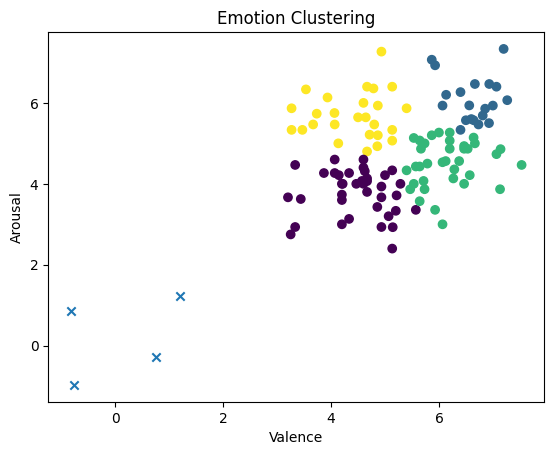

In [37]:
import matplotlib.pyplot as plt

plt.scatter(video_list_fixed_clean['AVG_Valence'], video_list_fixed_clean['AVG_Arousal'], c=video_list_fixed_clean['cluster'])

# cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], marker='x')

plt.xlabel('Valence')
plt.ylabel('Arousal')
plt.title('Emotion Clustering')
plt.show()

In [38]:
from sklearn.cluster import KMeans

inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

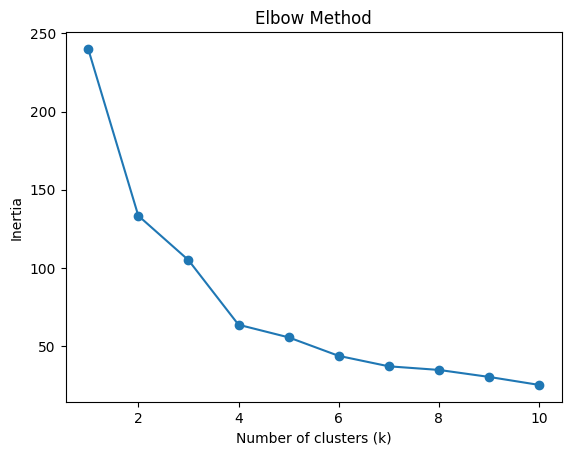

In [39]:
import matplotlib.pyplot as plt

plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [40]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.392
k=3, silhouette=0.318
k=4, silhouette=0.393
k=5, silhouette=0.339
k=6, silhouette=0.368
k=7, silhouette=0.380
k=8, silhouette=0.337
k=9, silhouette=0.338
k=10, silhouette=0.356
